<a href="https://colab.research.google.com/github/hsb0205/AI-CLASS/blob/main/WEEK06/abalone_DL_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/WEEK06/abalone.csv'

In [2]:
# abalone.csv 파일을 바탕으로 딥러닝(Deep Learning) regression 실습

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# CSV 파일을 DataFrame 형태로 읽기
df = pd.read_csv(path)
df

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...,...
4172,4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [3]:
# 데이터 전체 확인
df

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...,...
4172,4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [4]:
# 컬럼명 확인
df.columns

Index(['id', 'Sex', 'Length', 'Diameter', 'Height', 'Whole_weight',
       'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings'],
      dtype='object')

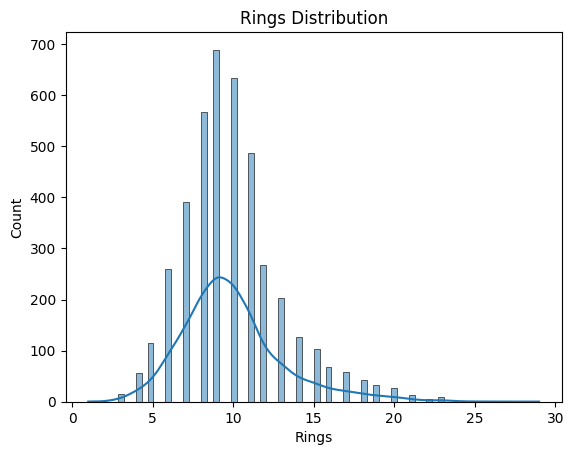

In [5]:
# 정답 데이터(Rings) 분포 확인
sns.histplot(df['Rings'], kde=True)
plt.xlabel("Rings")
plt.ylabel("Count")
plt.title("Rings Distribution")
plt.show()

In [6]:
# 결측치 확인
df.isnull().sum()

,0
id,0
Sex,0
Length,0
Diameter,0
Height,0
Whole_weight,0
Shucked_weight,0
Viscera_weight,0
Shell_weight,0
Rings,0


In [7]:
# 결측치 제거
df = df.dropna()
df.isnull().sum()

,0
id,0
Sex,0
Length,0
Diameter,0
Height,0
Whole_weight,0
Shucked_weight,0
Viscera_weight,0
Shell_weight,0
Rings,0


In [23]:
# 정답 데이터(y) 설정
# Rings는 연속형 수치값이므로 회귀(regression)의 목표값으로 사용한다.
y = df['Rings']
print(y.head())

0    15
1     7
2     9
3    10
4     7
Name: Rings, dtype: int64


In [24]:
# 입력 데이터(X) 생성
# Rings 정답 값이므로 입력 데이터에서 제거
# Sex 열도 분류용 레이블 성격이므로 입력 변수에서 제거
X = df.drop(['Rings', 'Sex'], axis=1)
X.head()

,id,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
0,0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150
1,1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070
2,2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210
3,3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155
4,4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055


In [25]:
# 입력 데이터와 정답 데이터의 크기 확인
# X는 (데이터 개수, feature 개수), y는 (데이터 개수,) 형태가 된다.
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4177, 8)
y shape: (4177,)


In [26]:
# 딥러닝 입력을 위해 DataFrame을 Numpy 배열로 변환
y = y.values

In [27]:
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler

# 데이터 표준화
# 표준화는 데이터의 각 feature를 비슷한 크기 범위로 맞추는 작업이다.
# 각 feature의 평균을 0, 표준편차를 1에 가깝게 맞춰 학습 성능을 높인다.
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [28]:
from sklearn.model_selection import train_test_split

# 학습용 데이터와 테스트용 데이터 분리
# test_size=0.2 -> 전체 데이터의 20%를 테스트용으로 사용
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [29]:
# 딥러닝 회귀 모델 생성
# 입력층 -> 은닉층1 -> Dropout -> 은닉층2 -> 출력층 구조
# 출력층은 회귀 문제이므로 예측값 1개만 출력한다.
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X.shape[1],)),  # X.shape[1] = 입력 feature의 개수
    layers.Dropout(0.3),     # 과적합 방지를 위해 일부 뉴런을 무작위로 비활성화
    layers.Dense(32, activation='relu'),
    layers.Dense(1)    # 회귀이므로 예측값 1개를 출력
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
# 모델 컴파일
# 회귀에서는 보통 MSE(평균제곱오차)와 MAE(평균절대오차)를 사용
# optimizer='adam' : 가중치 최적화 방법
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [31]:
# 모델 학습
# # 회귀에서는 보통 MSE(평균제곱오차)와 MAE(평균절대오차)를 사용
# validation_split=0.2 : 학습 데이터 중 20%를 검증용으로 사용
# epochs=50 : 전체 데이터를 50번 반복 학습
# batch_size=16 : 한 번에 16개씩 나누어 학습
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 47.6970 - mae: 5.7172 - val_loss: 16.9345 - val_mae: 3.1375
Epoch 2/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12.9509 - mae: 2.5385 - val_loss: 7.0889 - val_mae: 1.9046
Epoch 3/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8.4873 - mae: 2.0979 - val_loss: 6.3701 - val_mae: 1.7840
Epoch 4/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.1303 - mae: 1.9925 - val_loss: 6.1707 - val_mae: 1.7545
Epoch 5/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7945 - mae: 1.9172 - val_loss: 5.6614 - val_mae: 1.7179
Epoch 6/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8509 - mae: 1.8642 - val_loss: 5.4779 - val_mae: 1.6757
Epoch 7/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2990 - mae: 1.8213 - val_loss: 5.3511 - val_mae: 1.6599
Epoch 8/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1805 - mae: 1.8171 - val_loss: 5.3291 - val_mae: 1.6824
Epoch 9/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step -

In [32]:
# 테스트 데이터 예측
y_pred = model.predict(X_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [33]:
# 1차원 배열로 변환
y_pred = y_pred.flatten()

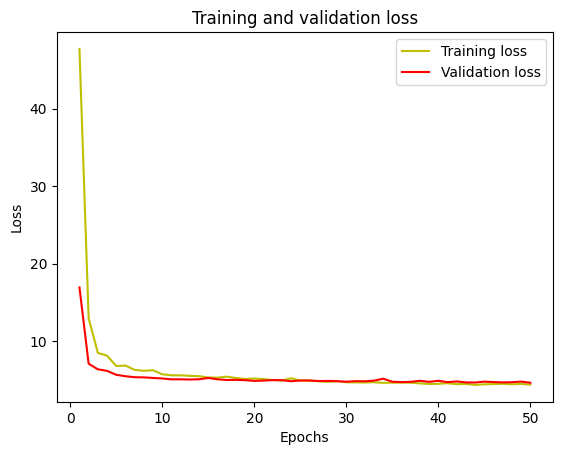

In [34]:
# 학습 손실값 추출
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

# Loss 그래프
# 학습 데이터와 검증 데이터의 손실값 변화를 확인한다.
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

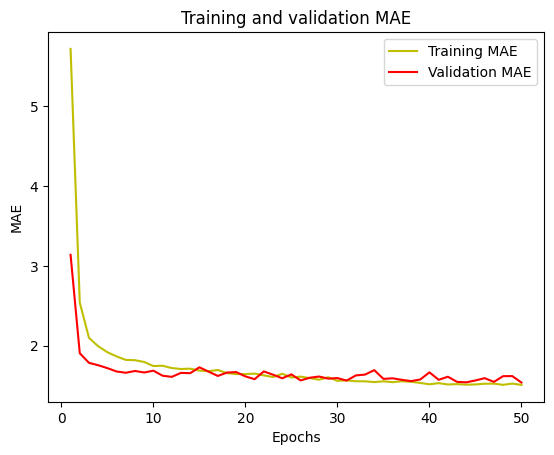

In [35]:
# MAE 값 추출
mae = history.history['mae']
val_mae = history.history['val_mae']

# MAE 그래프
# 학습 데이터와 검증 데이터의 평균절대오차 변화를 확인한다.
plt.plot(epochs, mae, 'y', label='Training MAE')
plt.plot(epochs, val_mae, 'r', label='Validation MAE')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

In [36]:
# 회귀 성능 평가
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 4.39240837097168
MAE: 1.4581800699234009
RMSE: 2.0958073315483174
R2 Score: 0.5955541133880615
